<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 7: Técnicas de regresión lineal
        </td>
    </tr>
    <tr>
 

</table>

<h1>Regresión Lineal - II</h1>

Un investigador desea analizar la relación entre el número de días de preparación para un examen y el puntaje obtenido por un estudiante en una prueba de práctica. Durante 20 días se registraron los resultados obtenidos en distintos intentos de evaluación.

<table border="1" cellpadding="6" cellspacing="0">
  <tr>
    <th>Día</th>
    <td>1</td>
    <td>2</td>
    <td>3</td>
    <td>4</td>
    <td>5</td>
    <td>6</td>
    <td>7</td>
    <td>8</td>
    <td>9</td>
    <td>10</td>
    <td>11</td>
    <td>12</td>
    <td>13</td>
    <td>14</td>
    <td>15</td>
    <td>16</td>
    <td>17</td>
    <td>18</td>
    <td>19</td>
    <td>20</td>
  </tr>
  <tr>
    <th>Valor (y)</th>
    <td>3</td>
    <td>25</td>
    <td>16</td>
    <td>7</td>
    <td>29</td>
    <td>9</td>
    <td>11</td>
    <td>23</td>
    <td>4</td>
    <td>5</td>
    <td>13</td>
    <td>11</td>
    <td>2</td>
    <td>8</td>
    <td>10</td>
    <td>9</td>
    <td>8</td>
    <td>7</td>
    <td>28</td>
    <td>29</td>
  </tr>
</table>


- Realizar un gráfico de dispersión que permita visualizar la relación entre ambas variables.

- Ajustar un modelo de regresión lineal simple de la forma $Y=\beta_0+ \beta_1X$ donde $X$ representa los días e $Y$ representa el puntaje

- Determinar la ecuación estimada del modelo.

- Estimar:El puntaje esperado en la pruba el estudiar 5 días y el puntaje esperado al estudiar 15 días.
- Calcular e interpretar
    - El error cuadrático medio.
    - El RMSE.
    - El coeficiente de determinación
      
- Analizar los residuos:
    - Realizar la representación gráfica.
    - Verificar la normalidad.
    - Verificar la homocedasticidad
 
- Construir el intervalo de confianza al 95% para verificar si la variable $X$ es significativa.

a) Se construye un gráfico de dispersión con el propósito de visualizar la relación existente entre ambas variables. Cada punto en el gráfico representa una observación del conjunto de datos y permite identificar patrones, tendencias o posibles asociaciones entre las variables analizadas

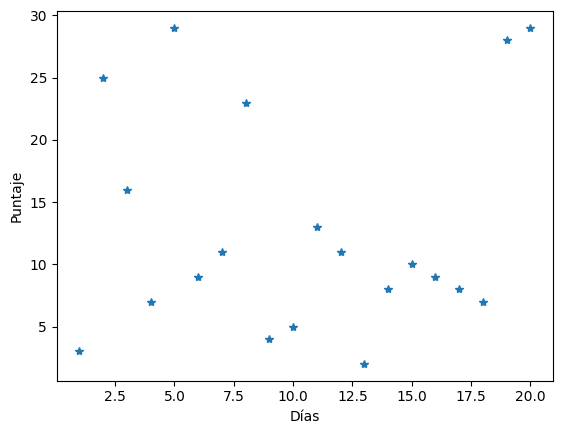

In [ ]:
import numpy as np # Librería numérica
import matplotlib.pyplot as plt # Para crear gráficos con matplotlib
from sklearn.linear_model import LinearRegression # Regresión Lineal con scikit-learn

dias   = np.arange(1,21) #[1,2,3,4,...,20]
puntaje = np.array([3, 25, 16, 7, 29, 9, 11, 23, 4,  5, 13, 11,  2,  8, 10,  9,  8,  7, 28, 29])

plt.figure()
plt.plot(dias, puntaje, '*')
plt.xlabel("Días")
plt.ylabel("Puntaje")
plt.show()

b) Se ajusta un modelo de regresión lineal simple de la forma $Y=\beta_0+\beta_1X$, donde $X$ representa los días y $Y$ el puntaje. Para estimar los parámetros del modelo se utiliza la clase `LinearRegression()` de la librería `sklearn.linear_model` en Python.  

Este procedimiento permite obtener el intercepto $\beta_0$ y la pendiente $\beta_1$, los cuales describen la relación lineal entre ambas variables y permiten analizar cómo varía el puntaje en función de los días.

In [ ]:
# Importamos la clase de Regresión Lineal de scikit-learn
from sklearn.linear_model import LinearRegression

#Creamos una instancia de LinearRegression
lineal_regresion = LinearRegression()
#Instruimos a la regresión lineal que aprenda de los datos (x, y)
lineal_regresion.fit(dias.reshape(-1,1), puntaje) #entrenar el modelo

#Vemos los parámetros que ha estimado la regresión lineal
print("El coeficiente es %s y el intercepto es %s"%(lineal_regresion.coef_, lineal_regresion.intercept_))

El coeficiente es [0.08646617] y el intercepto es 11.942105263157895


c) La ecuación de la recta viene dada por: 

In [ ]:
print("La recta de regresión es y= %s x + %s"%(lineal_regresion.coef_, lineal_regresion.intercept_))

La recta de regresión es y= [0.08646617] x + 11.942105263157895


d) Una vez ajustado el modelo de regresión lineal simple, se utiliza el modelo obtenido para estimar el puntaje esperado cuando se estudia durante 5 días y cuando se estudia durante 15 días.

In [ ]:
# vamos a predicir y = regresion_lineal(5) con nuevo_x
nuevo_x = np.array([5])

prediccion = lineal_regresion.predict(nuevo_x.reshape(-1,1))
print("El puntaje esperado al estudiar 5 dias es %s"%prediccion)

El puntaje esperado al estudiar 5 dias es [12.37443609]


In [ ]:
# vamos a predicir y = regresion_lineal(15) con nuevo2_x
nuevo2_x = np.array([15])

prediccion2 = lineal_regresion.predict(nuevo2_x.reshape(-1,1))
print("El puntaje esperado al estudiar 15 dias es %s"%prediccion2)

El puntaje esperado al estudiar 15 dias es [13.23909774]



e) Posteriormente, se evalúa el desempeño del modelo mediante las siguientes métricas:

- Error Cuadrático Medio (MSE): mide el promedio de los cuadrados de las diferencias entre los valores reales y los valores predichos por el modelo. Un valor menor indica un mejor ajuste del modelo a los datos.

- Raíz del Error Cuadrático Medio (RMSE): corresponde a la raíz cuadrada del MSE y expresa el error promedio de las predicciones en las mismas unidades de la variable respuesta.

- Coeficiente de determinación ($R^2$): indica la proporción de la variabilidad del puntaje que es explicada por el modelo de regresión lineal. Valores cercanos a 1 indican que el modelo explica adecuadamente la variación de los datos.

In [ ]:
# importamos el cálculo del error cuadrático medio (MSE)
from sklearn.metrics import mean_squared_error

# Predecimos los valores y para los datos usados en el entrenamiento
prediccion = lineal_regresion.predict(dias.reshape(-1,1))

# Calculamos el Error Cuadrático Medio (MSE = Mean Squared Error)
mse = mean_squared_error(y_true= puntaje, y_pred=prediccion)
print("El error cuadratico medio es %s"%mse)

# La raíz cuadrada del MSE es el RMSE
rsme = np.sqrt(mse)
print("El rsme del modelo %s"%rsme)

El error cuadratico medio es 76.0789097744361
El rsme del modelo 8.722322498878157


In [ ]:
# calculamos el coeficiente de determinación R2
r2 = lineal_regresion.score(dias.reshape(-1,1), puntaje)
print("El coeficiente de determinación es %s"%r2)

El coeficiente de determinación es 0.0032568893984985525


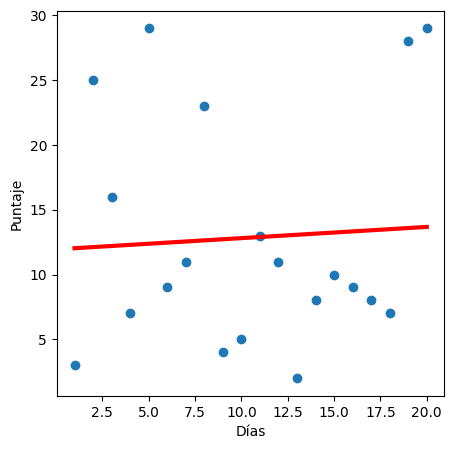

In [ ]:
# Obtener valores modelo

# Representar x e y
fig = plt.figure(figsize=(5,5))
plt.scatter(dias, puntaje)

x = dias.reshape(-1,1)

# Representar la recta de regresion
y_pred = lineal_regresion.predict(x)
plt.plot(dias, y_pred, color='red', linewidth=3)

# Definir ejes
plt.xlabel("Días")
plt.ylabel("Puntaje")

# Mostrar grafico
plt.show()

In [ ]:
# la recta debe pasar por el punto:
print("(%s, %s)" %(dias.mean(),puntaje.mean()))

(10.5, 12.85)


In [ ]:
# calcular sigma2
print("Varianza del modelo, s2: %.2f"% mean_squared_error(puntaje, y_pred))

Varianza del modelo, s2: 76.08


In [ ]:
# estimador de la varianza por MLE (método de máxima verosimilitud)
y_resta = (puntaje - y_pred) ** 2
sum(y_resta)/20

np.float64(76.07890977443608)

In [ ]:
# estimador de la varianza por OLS (mínimos cuadrados ordinarios)
y_resta = (puntaje - y_pred) ** 2
sum(y_resta)/(20-2) # 6-2

np.float64(84.53212197159566)

f) Se analizan los residuos del modelo de regresión lineal con el objetivo de verificar si se cumplen los supuestos del modelo.

* Representación gráfica de los residuos: se construye un gráfico de dispersión de los residuos frente a los valores ajustados o frente a la variable independiente. Este gráfico permite identificar posibles patrones, tendencias o estructuras que indiquen un mal ajuste del modelo.

* Verificación de la normalidad: se analiza si los residuos siguen aproximadamente una distribución normal.
  
* Verificación de la homocedasticidad: se comprueba si la varianza de los residuos permanece aproximadamente constante a lo largo de los valores ajustados. Si los residuos presentan una dispersión similar en todo el rango de predicción, se considera que el supuesto de homocedasticidad se cumple.


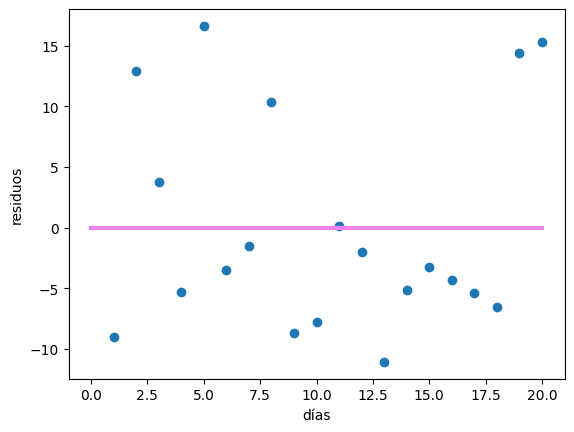

In [ ]:
# obtener residuos
residuos = puntaje - y_pred
plt.scatter(x, residuos)
plt.xlabel("días")
plt.ylabel("residuos")
plt.plot([0, np.max(x)], [0, 0], color = 'violet', linewidth = 3)
plt.show()

In [ ]:
import scipy.stats as stats

# se realiza la prueba S-W
sh_result = stats.shapiro(residuos)

# dar formato a la salida
print("Test Shapiro-Wilk, p.valor: %5.5f" %(sh_result.pvalue))
print("Como p.valor < 0.05, se rechaza la hipótesis nula y no se da normalidad en los residuos.")

Test Shapiro-Wilk, p.valor: 0.00755
Como p.valor < 0.05, se rechaza la hipótesis nula y no se da normalidad en los residuos.


In [ ]:
import statsmodels.api as sm
import statsmodels.stats.api as sms

m1 = sm.OLS(puntaje, sm.add_constant(x)).fit()
bp1 = sms.het_breuschpagan(resid = m1.resid, exog_het = m1.model.exog)[1]
print("El resultado del test Breusch-Pagan es: p.valor = %5.3f"%(bp1))
print("Como p.valor > 0.05, no se rechaza la hipótesis nula y se da homocedasticidad.")

El resultado del test Breusch-Pagan es: p.valor = 0.780
Como p.valor > 0.05, no se rechaza la hipótesis nula y se da homocedasticidad.


g) Se construye el intervalo de confianza al 95% para el coeficiente asociado a la variable $X$ con el objetivo de evaluar su significancia en el modelo de regresión lineal.

Este intervalo permite determinar un rango plausible de valores para el parámetro $\beta_1$. Si el valor 0 no pertenece al intervalo de confianza, se concluye que la variable $X$ tiene un efecto significativo sobre la variable respuesta $Y$. En caso contrario, no se cuenta con evidencia suficiente para afirmar que $X$ influye significativamente en $Y$.

In [ ]:
# calcular ICbeta1
y_resta = (puntaje-y_pred)**2
# calcular numerador sb1^2
s2 = sum(y_resta)/(len(puntaje)-2)

# calcular denominador sb1^2
den = np.var(x) * len(x)

# calcular sb1
sb1 = (s2/den) ** 0.5
amplitud = 1.96 * sb1
print("El IC al 0.95 de b1 es:", lineal_regresion.coef_, "+/-", amplitud)
print("El intervalo de confianza contiene al 0 para beta_1, luego, la variable no es significativa.")

El IC al 0.95 de b1 es: [0.08646617] +/- 0.6988052099496359
El intervalo de confianza contiene al 0 para beta_1, luego, la variable no es significativa.


In [ ]:
0.08646617 + 0.6988052099496359

0.7852713799496359

In [ ]:
0.08646617 - 0.6988052099496359

-0.6123390399496359

Fin